In [ ]:

from __future__ import print_function
import argparse
import math
import numpy as np
import numpy.random as npr
import scipy.misc
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
import os
import sys

from six.moves.urllib.request import urlretrieve
import tarfile
import pickle

def get_file(fname, origin, untar=False, extract=False, archive_format='auto', cache_dir='data'):
    datadir = os.path.join(cache_dir)
    if not os.path.exists(datadir):
        os.makedirs(datadir)
    if untar:
        untar_fpath = os.path.join(datadir, fname)
        fpath = untar_fpath + '.tar.gz'
    else:
        fpath = os.path.join(datadir, fname)
    print(fpath)
    if not os.path.exists(fpath):
        print('Downloading data from', origin)
        error_msg = 'URL fetch failure on {}: {} -- {}'
        try:
            try:
                urlretrieve(origin, fpath)
            except Exception as e:
                raise Exception(error_msg.format(origin, type(e).__name__, str(e)))
        except (Exception, KeyboardInterrupt) as e:
            if os.path.exists(fpath):
                os.remove(fpath)
            raise
    if untar:
        if not os.path.exists(untar_fpath):
            print('Extracting file.')
            with tarfile.open(fpath) as archive:
                archive.extractall(datadir)
        return untar_fpath
    return fpath

def load_batch(fpath, label_key='labels'):
    with open(fpath, 'rb') as f:
        if sys.version_info < (3,):
            d = pickle.load(f)
        else:
            d = pickle.load(f, encoding='bytes')
        d_decoded = {}
        for k, v in d.items():
            d_decoded[k.decode('utf8')] = v
        d = d_decoded
    data = d['data']
    labels = d[label_key]
    data = data.reshape(data.shape[0], 3, 32, 32)
    return data, labels

def load_cifar10(transpose=False):
    dirname = 'cifar-10-batches-py'
    origin = 'http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
    path = get_file(dirname, origin=origin, untar=True)
    num_train_samples = 50000
    x_train = np.zeros((num_train_samples, 3, 32, 32), dtype='uint8')
    y_train = np.zeros((num_train_samples,), dtype='uint8')
    for i in range(1, 6):
        fpath = os.path.join(path, 'data_batch_' + str(i))
        data, labels = load_batch(fpath)
        x_train[(i - 1) * 10000: i * 10000, :, :, :] = data
        y_train[(i - 1) * 10000: i * 10000] = labels
    fpath = os.path.join(path, 'test_batch')
    x_test, y_test = load_batch(fpath)
    y_train = np.reshape(y_train, (len(y_train), 1))
    y_test = np.reshape(y_test, (len(y_test), 1))
    if transpose:
        x_train = x_train.transpose(0, 2, 3, 1)
        x_test = x_test.transpose(0, 2, 3, 1)
    return (x_train, y_train), (x_test, y_test)

colours_fpath = get_file(fname='colours', 
                         origin='http://www.cs.toronto.edu/~jba/kmeans_colour_a2.tar.gz', 
                         untar=True)

HORSE_CATEGORY = 7

colour_data = np.load("./data/colours/colour_kmeans24_cat7.npy", allow_pickle=True, encoding='latin1')
if isinstance(colour_data, (list, tuple)) or (isinstance(colour_data, np.ndarray) and colour_data.dtype == object):
    COLOUR_CENTERS = torch.from_numpy(np.array(colour_data[0], dtype=np.float32))
else:
    COLOUR_CENTERS = torch.from_numpy(np.array(colour_data, dtype=np.float32))

print("Color centers loaded successfully!")
print("Shape:", COLOUR_CENTERS.shape)
NUM_COLOURS = COLOUR_CENTERS.shape[0]

def get_rgb_cat(xs, colours):
    if np.shape(xs)[0] < 100:
        return _get_rgb_cat(xs, colours)
    batch_size = 100
    nexts = []
    for i in range(0, np.shape(xs)[0], batch_size):
        next = _get_rgb_cat(xs[i:i+batch_size,:,:,:], colours)
        nexts.append(next)
    result = np.concatenate(nexts, axis=0)
    return result

def _get_rgb_cat(xs, colours):
    num_colours = np.shape(colours)[0]
    xs = np.expand_dims(xs, 0)
    cs = np.reshape(colours, [num_colours,1,3,1,1])
    dists = np.linalg.norm(xs - cs, axis=2)
    cat = np.argmin(dists, axis=0)
    cat = np.expand_dims(cat, axis=1)
    return cat

def get_cat_rgb(cats, colours):
    if cats.ndim == 4 and cats.shape[1] == 1:
        cats = cats.squeeze(1)
    elif cats.ndim == 2:
        cats = np.expand_dims(cats, 0)
    return colours[cats]

def process(xs, ys, max_pixel=256.0, downsize_input=False):
    xs = xs / max_pixel
    xs = xs[np.where(ys == HORSE_CATEGORY)[0], :, :, :]
    npr.shuffle(xs)
    grey = np.mean(xs, axis=1, keepdims=True)
    if downsize_input:
        downsize_module = nn.Sequential(
            nn.AvgPool2d(2), 
            nn.AvgPool2d(2), 
            nn.Upsample(scale_factor=2), 
            nn.Upsample(scale_factor=2)
        )
        xs_downsized = downsize_module.forward(torch.from_numpy(xs).float())
        xs_downsized = xs_downsized.data.numpy()
        return (xs, xs_downsized)
    else:
        return (xs, grey)

def get_batch(x, y, batch_size):
    N = np.shape(x)[0]
    assert N == np.shape(y)[0]
    for i in range(0, N, batch_size):
        batch_x = x[i:i+batch_size, :,:,:]
        batch_y = y[i:i+batch_size, :,:,:]
        yield (batch_x, batch_y)

def get_torch_vars(xs, ys, gpu=False):
    xs = torch.from_numpy(xs).float()
    ys = torch.from_numpy(ys).long()
    if gpu and torch.cuda.is_available():
        xs = xs.cuda()
        ys = ys.cuda()
    return Variable(xs), Variable(ys)

def compute_loss(criterion, outputs, labels, batch_size, num_colours):
    loss_out = outputs.transpose(1, 3).contiguous().view([batch_size * 32 * 32, num_colours])
    loss_lab = labels.transpose(1, 3).contiguous().view([batch_size * 32 * 32])
    return criterion(loss_out, loss_lab)

class MyConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=None):
        super(MyConv2d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        if padding is None:
            self.padding = kernel_size // 2
        else:
            self.padding = padding
        self.weight = nn.parameter.Parameter(torch.Tensor(
            out_channels, in_channels, kernel_size, kernel_size))
        self.bias = nn.parameter.Parameter(torch.Tensor(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        n = self.in_channels * self.kernel_size * self.kernel_size
        stdv = 1. / math.sqrt(n)
        self.weight.data.uniform_(-stdv, stdv)
        self.bias.data.uniform_(-stdv, stdv)

    def forward(self, input):
        return F.conv2d(input, self.weight, self.bias, padding=self.padding)

class CNN(nn.Module):
    def __init__(self, kernel, num_filters, num_colours, num_in_channels):
        super(CNN, self).__init__()
        padding = kernel // 2
        self.downconv1 = nn.Sequential(
            MyConv2d(num_in_channels, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.downconv2 = nn.Sequential(
            MyConv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.rfconv = nn.Sequential(
            MyConv2d(num_filters*2, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU()
        )
        self.upconv1 = nn.Sequential(
            MyConv2d(num_filters*2, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
        )
        self.upconv2 = nn.Sequential(
            MyConv2d(num_filters, num_colours, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_colours),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
        )
        self.finalconv = MyConv2d(num_colours, num_colours, kernel_size=kernel)

    def forward(self, x):
        self.out1 = self.downconv1(x)
        self.out2 = self.downconv2(self.out1)
        self.out3 = self.rfconv(self.out2)
        self.out4 = self.upconv1(self.out3)
        self.out5 = self.upconv2(self.out4)
        self.out_final = self.finalconv(self.out5)
        return self.out_final

class UNet(nn.Module):
    def __init__(self, kernel, num_filters, num_colours, num_in_channels):
        super(UNet, self).__init__()
        padding = kernel // 2
        self.downconv1 = nn.Sequential(
            MyConv2d(num_in_channels, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.downconv2 = nn.Sequential(
            MyConv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.rfconv = nn.Sequential(
            MyConv2d(num_filters*2, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU()
        )
        self.upconv1 = nn.Sequential(
            MyConv2d(num_filters*4, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
        )
        self.upconv2 = nn.Sequential(
            MyConv2d(num_filters*2, num_colours, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_colours),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
        )
        self.finalconv = MyConv2d(num_colours + num_in_channels, num_colours, kernel_size=kernel)

    def forward(self, x):
        self.out1 = self.downconv1(x)
        self.out2 = self.downconv2(self.out1)
        self.out3 = self.rfconv(self.out2)
        self.out4 = self.upconv1(torch.cat([self.out3, self.out2], dim=1))
        self.out5 = self.upconv2(torch.cat([self.out4, self.out1], dim=1))
        self.out_final = self.finalconv(torch.cat([self.out5, x], dim=1))
        return self.out_final

def plot(input, gtlabel, output, colours, path, visualize, compare_bilinear=False):
    grey = np.transpose(input[:10, :, :, :], [0, 2, 3, 1])
    gtlabel_squeezed = gtlabel[:10, 0, :, :]
    output_squeezed = output[:10, 0, :, :]
    gtcolor = get_cat_rgb(gtlabel_squeezed, colours)
    predcolor = get_cat_rgb(output_squeezed, colours)
    
    img_stack = [
        np.hstack(np.tile(grey, [1, 1, 1, 3])),
        np.hstack(gtcolor),
        np.hstack(predcolor)
    ]
    
    if compare_bilinear:
        downsize_module = nn.Sequential(
            nn.AvgPool2d(2),
            nn.AvgPool2d(2),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Upsample(scale_factor=2, mode='bilinear')
        )
        gt_input = np.transpose(gtcolor, [0, 3, 1, 2])
        color_bilinear = downsize_module.forward(torch.from_numpy(gt_input).float())
        color_bilinear = np.transpose(color_bilinear.data.numpy(), [0, 2, 3, 1])
        img_stack.append(np.hstack(color_bilinear))
    
    img = np.vstack(img_stack)
    plt.grid('off')
    plt.imshow(img, vmin=0., vmax=1.)
    
    if visualize:
        plt.show()
    else:
        plt.savefig(path)
    plt.close()

def run_validation_step(cnn, criterion, test_grey, test_rgb_cat, batch_size, colours, 
                        plotpath=None, visualize=True, downsize_input=False, gpu=False):
    correct = 0.0
    total = 0.0
    losses = []
    num_colours = np.shape(colours)[0]
    
    for i, (xs, ys) in enumerate(get_batch(test_grey, test_rgb_cat, batch_size)):
        images, labels = get_torch_vars(xs, ys, gpu)
        outputs = cnn(images)
        
        val_loss = compute_loss(criterion, outputs, labels, batch_size=batch_size, 
                               num_colours=num_colours)
        losses.append(val_loss.data.item())
        
        _, predicted = torch.max(outputs.data, 1, keepdim=True)
        total += labels.size(0) * 32 * 32
        correct += (predicted == labels.data).sum()
        
        if plotpath and i == 0:
            plot(xs, ys, predicted.cpu().numpy(), colours, plotpath, 
                 visualize=visualize, compare_bilinear=downsize_input)
    
    val_loss = np.mean(losses)
    val_acc = 100 * correct / total
    return val_loss, val_acc

def plot_activation(args, cnn):
   
    colours = np.load(args['colours'], allow_pickle=True, encoding='latin1')[0]
    num_colours = np.shape(colours)[0]
    
    (x_train, y_train), (x_test, y_test) = load_cifar10()
    test_rgb, test_grey = process(x_test, y_test, downsize_input=args['downsize_input'])
    test_rgb_cat = get_rgb_cat(test_rgb, colours)
    
    id = args['index']
    outdir = "outputs/" + args['experiment_name'] + '/act' + str(id)
    if not os.path.exists(outdir):
        os.makedirs(outdir)
    
    images, labels = get_torch_vars(np.expand_dims(test_grey[id], 0), 
                                    np.expand_dims(test_rgb_cat[id], 0))
    cnn.cpu()
    outputs = cnn(images)
    _, predicted = torch.max(outputs.data, 1, keepdim=True)
    
  
    pred_categories = predicted.cpu().numpy()[0, 0, :, :]  
    
    
    predcolor = colours[pred_categories]
    
    
    if predcolor.ndim != 3:
        predcolor = predcolor.reshape(32, 32, 3)
    
    img_uint8 = (np.clip(predcolor, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(img_uint8).save(os.path.join(outdir, "output_%d.png" % id))
    
    if not args['downsize_input']:
        grey_img = np.tile(test_grey[id].transpose(1, 2, 0), [1, 1, 3])
    else:
        grey_img = test_grey[id].transpose(1, 2, 0)
        if grey_img.shape[2] == 1:
            grey_img = np.tile(grey_img, [1, 1, 3])
    
    grey_uint8 = (np.clip(grey_img, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(grey_uint8).save(os.path.join(outdir, "input_%d.png" % id))
    
    gt_img = test_rgb[id].transpose(1, 2, 0)
    gt_uint8 = (np.clip(gt_img, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(gt_uint8).save(os.path.join(outdir, "input_%d_gt.png" % id))
    
    def add_border(img):
        return np.pad(img, 1, "constant", constant_values=1.0)
    
    def draw_activations(path, activation, imgwidth=4):
        act = activation[0]
        C = act.shape[0]
        rows = []
        for i in range(0, C, imgwidth):
            row_filters = []
            for j in range(i, min(i + imgwidth, C)):
                row_filters.append(add_border(act[j]))
            while len(row_filters) < imgwidth:
                row_filters.append(np.zeros_like(row_filters[0]))
            rows.append(np.hstack(row_filters))
        img = np.vstack(rows)
        plt.imsave(path, img, cmap='viridis')
    
    for i, tensor in enumerate([cnn.out1, cnn.out2, cnn.out3, cnn.out4, cnn.out5]):
        draw_activations(os.path.join(outdir, "conv%d_out_%d.png" % (i+1, id)), 
                        tensor.data.cpu().numpy())
    
    print("Visualization results saved to %s" % outdir)

class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

def train(args, cnn=None):
    torch.set_num_threads(5)
    npr.seed(args.seed)
    
    save_dir = "outputs/" + args.experiment_name
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    colours = np.load(args.colours, allow_pickle=True, encoding='latin1')[0]
    num_colours = np.shape(colours)[0]
    
    num_in_channels = 1 if not args.downsize_input else 3
    
    if cnn is None:
        if args.model == "CNN":
            cnn = CNN(args.kernel, args.num_filters, num_colours, num_in_channels)
        elif args.model == "UNet":
            cnn = UNet(args.kernel, args.num_filters, num_colours, num_in_channels)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(cnn.parameters(), lr=args.learn_rate)
    
    print("Loading data...")
    (x_train, y_train), (x_test, y_test) = load_cifar10()
    print("Transforming data...")
    train_rgb, train_grey = process(x_train, y_train, downsize_input=args.downsize_input)
    train_rgb_cat = get_rgb_cat(train_rgb, colours)
    test_rgb, test_grey = process(x_test, y_test, downsize_input=args.downsize_input)
    test_rgb_cat = get_rgb_cat(test_rgb, colours)
    
    print("Beginning training ...")
    if args.gpu and torch.cuda.is_available():
        cnn.cuda()
        print("Using GPU")
    elif args.gpu:
        print("GPU not available, using CPU")
    else:
        print("Using CPU")
    
    start = time.time()
    train_losses = []
    valid_losses = []
    valid_accs = []
    
    for epoch in range(args.epochs):
        cnn.train()
        losses = []
        
        for i, (xs, ys) in enumerate(get_batch(train_grey, train_rgb_cat, args.batch_size)):
            images, labels = get_torch_vars(xs, ys, args.gpu and torch.cuda.is_available())
            
            optimizer.zero_grad()
            outputs = cnn(images)
            loss = compute_loss(criterion, outputs, labels, 
                              batch_size=args.batch_size, num_colours=num_colours)
            loss.backward()
            optimizer.step()
            losses.append(loss.data.item())
            
            if args.plot and i == 0:
                _, predicted = torch.max(outputs.data, 1, keepdim=True)
                plot(xs, ys, predicted.cpu().numpy(), colours, 
                     save_dir + '/train_%d.png' % epoch, args.visualize, args.downsize_input)
        
        avg_loss = np.mean(losses)
        train_losses.append(avg_loss)
        time_elapsed = time.time() - start
        print('Epoch [%d/%d], Loss: %.4f, Time (s): %d' % 
              (epoch+1, args.epochs, avg_loss, time_elapsed))
        
        cnn.eval()
        val_loss, val_acc = run_validation_step(cnn, criterion, test_grey, test_rgb_cat,
                                               args.batch_size, colours,
                                               save_dir + '/test_%d.png' % epoch,
                                               args.visualize, args.downsize_input, 
                                               args.gpu and torch.cuda.is_available())
        time_elapsed = time.time() - start
        valid_losses.append(val_loss)
        valid_accs.append(val_acc)
        print('Epoch [%d/%d], Val Loss: %.4f, Val Acc: %.1f%%, Time(s): %d' % 
              (epoch+1, args.epochs, val_loss, val_acc, time_elapsed))
    
    plt.figure()
    plt.plot(train_losses, "ro-", label="Train")
    plt.plot(valid_losses, "go-", label="Validation")
    plt.legend()
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.savefig(save_dir + "/training_curve.png")
    plt.close()
    
    if args.checkpoint:
        print('Saving model...')
        torch.save(cnn.state_dict(), args.checkpoint)
    
    return cnn

if __name__ == "__main__":
    use_gpu = torch.cuda.is_available()
    print(f"GPU Available: {use_gpu}")
    
    print("=" * 60)
    print("TRAINING CNN MODEL")
    print("=" * 60)
    
    args = AttrDict()
    args_dict = {
        'gpu': False,
        'valid': False,
        'checkpoint': "outputs/cnn_model.pth",
        'colours': './data/colours/colour_kmeans24_cat7.npy',
        'model': "CNN",
        'kernel': 3,
        'num_filters': 32,
        'learn_rate': 0.001,
        'batch_size': 100,
        'epochs': 25,
        'seed': 0,
        'plot': True,
        'experiment_name': 'colourization_cnn',
        'visualize': False,
        'downsize_input': False,
    }
    args.update(args_dict)
    cnn = train(args)
    
    print("\n" + "=" * 60)
    print("TRAINING UNET MODEL")
    print("=" * 60)
    
    args = AttrDict()
    args_dict = {
        'gpu': False,
        'valid': False,
        'checkpoint': "outputs/unet_model.pth",
        'colours': './data/colours/colour_kmeans24_cat7.npy',
        'model': "UNet",
        'kernel': 3,
        'num_filters': 32,
        'learn_rate': 0.001,
        'batch_size': 100,
        'epochs': 25,
        'seed': 0,
        'plot': True,
        'experiment_name': 'colourization_unet',
        'visualize': False,
        'downsize_input': False,
    }
    args.update(args_dict)
    unet_cnn = train(args)
    
    print("\n" + "=" * 60)
    print("VISUALIZING ACTIVATIONS")
    print("=" * 60)
    
    args = AttrDict()
    args_dict = {
        'colours': './data/colours/colour_kmeans24_cat7.npy',
        'index': 0,
        'experiment_name': 'colourization_cnn',
        'downsize_input': False,
    }
    args.update(args_dict)
    plot_activation(args, cnn)
    
    args = AttrDict()
    args_dict = {
        'colours': './data/colours/colour_kmeans24_cat7.npy',
        'index': 0,
        'experiment_name': 'colourization_unet',
        'downsize_input': False,
    }
    args.update(args_dict)
    plot_activation(args, unet_cnn)
    
    print("\n" + "=" * 60)
    print("TRAINING COMPLETE!")
    print("=" * 60)

data\colours.tar.gz
Color centers loaded successfully!
Shape: torch.Size([24, 3])
GPU Available: False
TRAINING CNN MODEL
Loading data...
data\cifar-10-batches-py.tar.gz
Transforming data...


C:\Users\exam\AppData\Local\Temp\ipykernel_14504\3349427585.py:61: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='bytes')


Beginning training ...
Using CPU
Epoch [1/25], Loss: 2.4344, Time (s): 4
Epoch [1/25], Val Loss: 2.1273, Val Acc: 29.2%, Time(s): 5
Epoch [2/25], Loss: 1.9901, Time (s): 9
Epoch [2/25], Val Loss: 1.9085, Val Acc: 33.1%, Time(s): 10
Epoch [3/25], Loss: 1.8724, Time (s): 14
Epoch [3/25], Val Loss: 1.8131, Val Acc: 35.7%, Time(s): 15
Epoch [4/25], Loss: 1.8074, Time (s): 19
Epoch [4/25], Val Loss: 1.7602, Val Acc: 37.0%, Time(s): 19
Epoch [5/25], Loss: 1.7648, Time (s): 24
Epoch [5/25], Val Loss: 1.7323, Val Acc: 37.7%, Time(s): 24
Epoch [6/25], Loss: 1.7339, Time (s): 28
Epoch [6/25], Val Loss: 1.7079, Val Acc: 38.2%, Time(s): 29
Epoch [7/25], Loss: 1.7103, Time (s): 33
Epoch [7/25], Val Loss: 1.6900, Val Acc: 38.6%, Time(s): 34
Epoch [8/25], Loss: 1.6911, Time (s): 38
Epoch [8/25], Val Loss: 1.6754, Val Acc: 39.0%, Time(s): 38
Epoch [9/25], Loss: 1.6747, Time (s): 43
Epoch [9/25], Val Loss: 1.6601, Val Acc: 39.3%, Time(s): 43
Epoch [10/25], Loss: 1.6605, Time (s): 48
Epoch [10/25], Val 

DISPLAYING CNN RESULTS


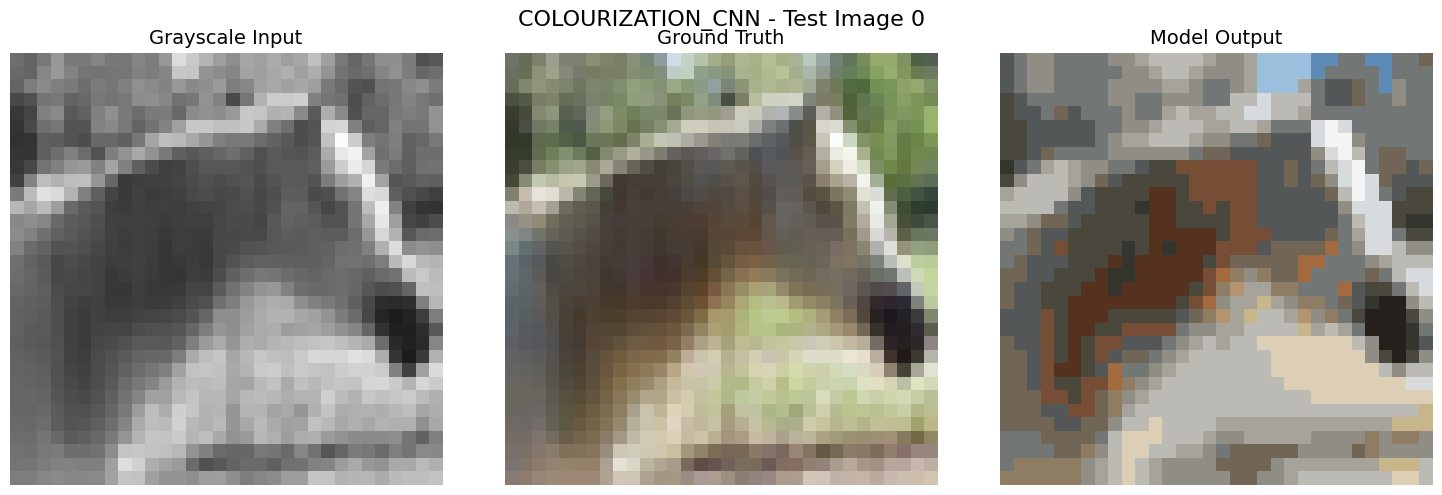

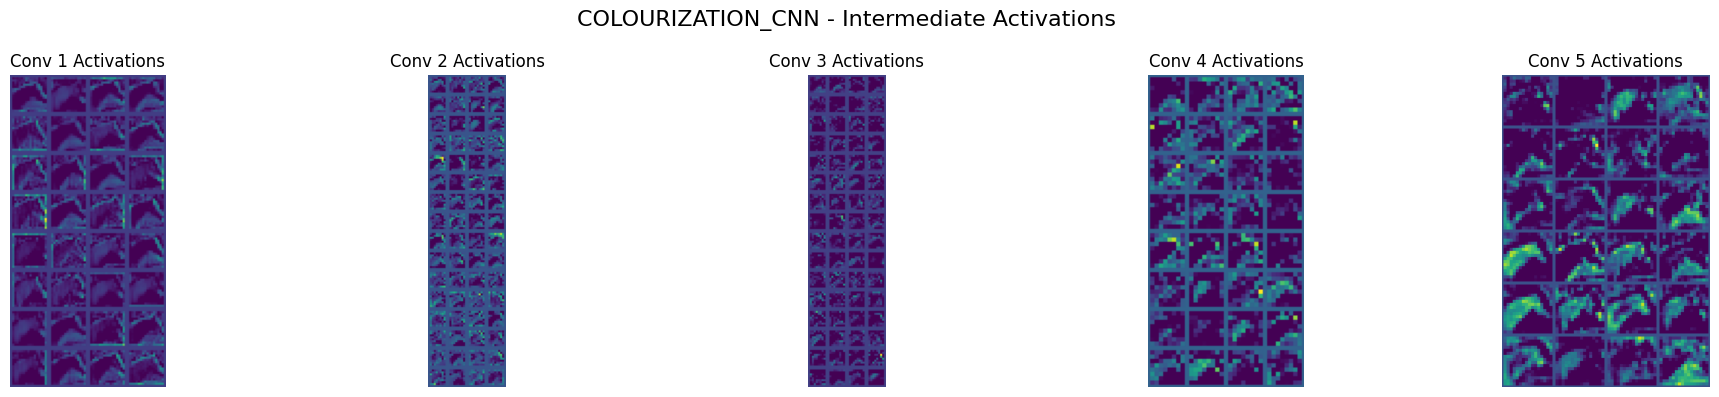


DISPLAYING UNET RESULTS


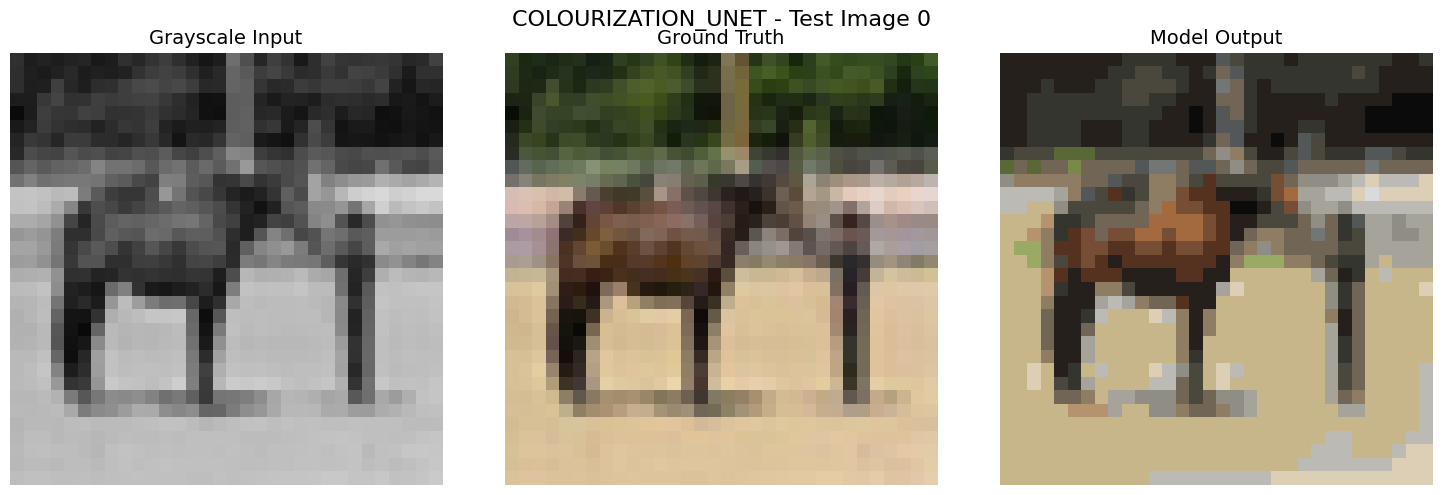

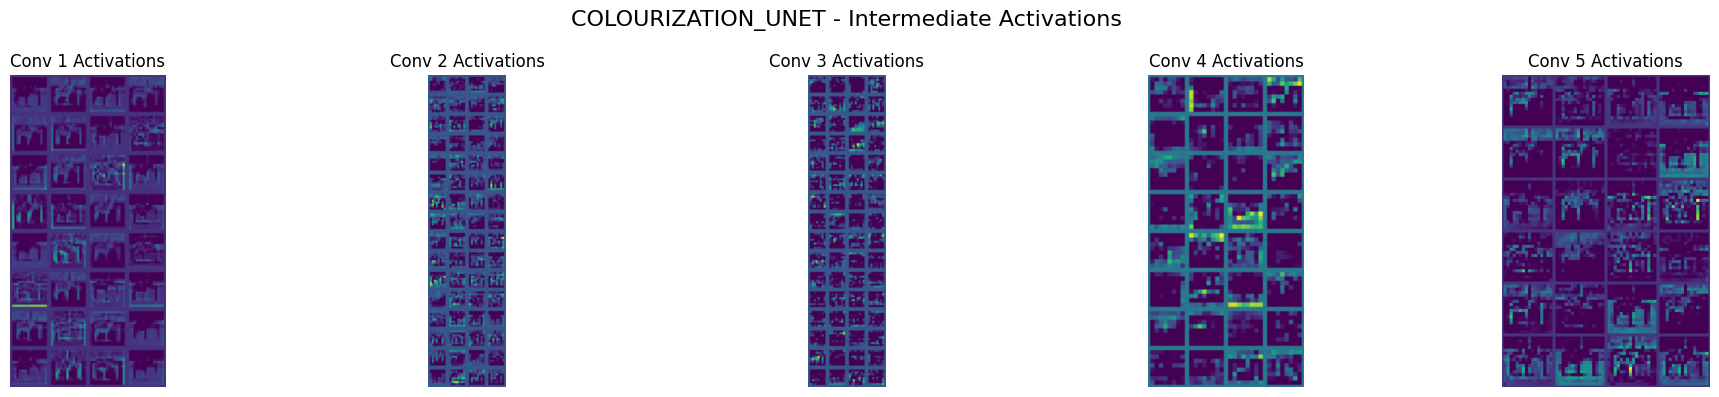


COMPARING CNN vs UNET


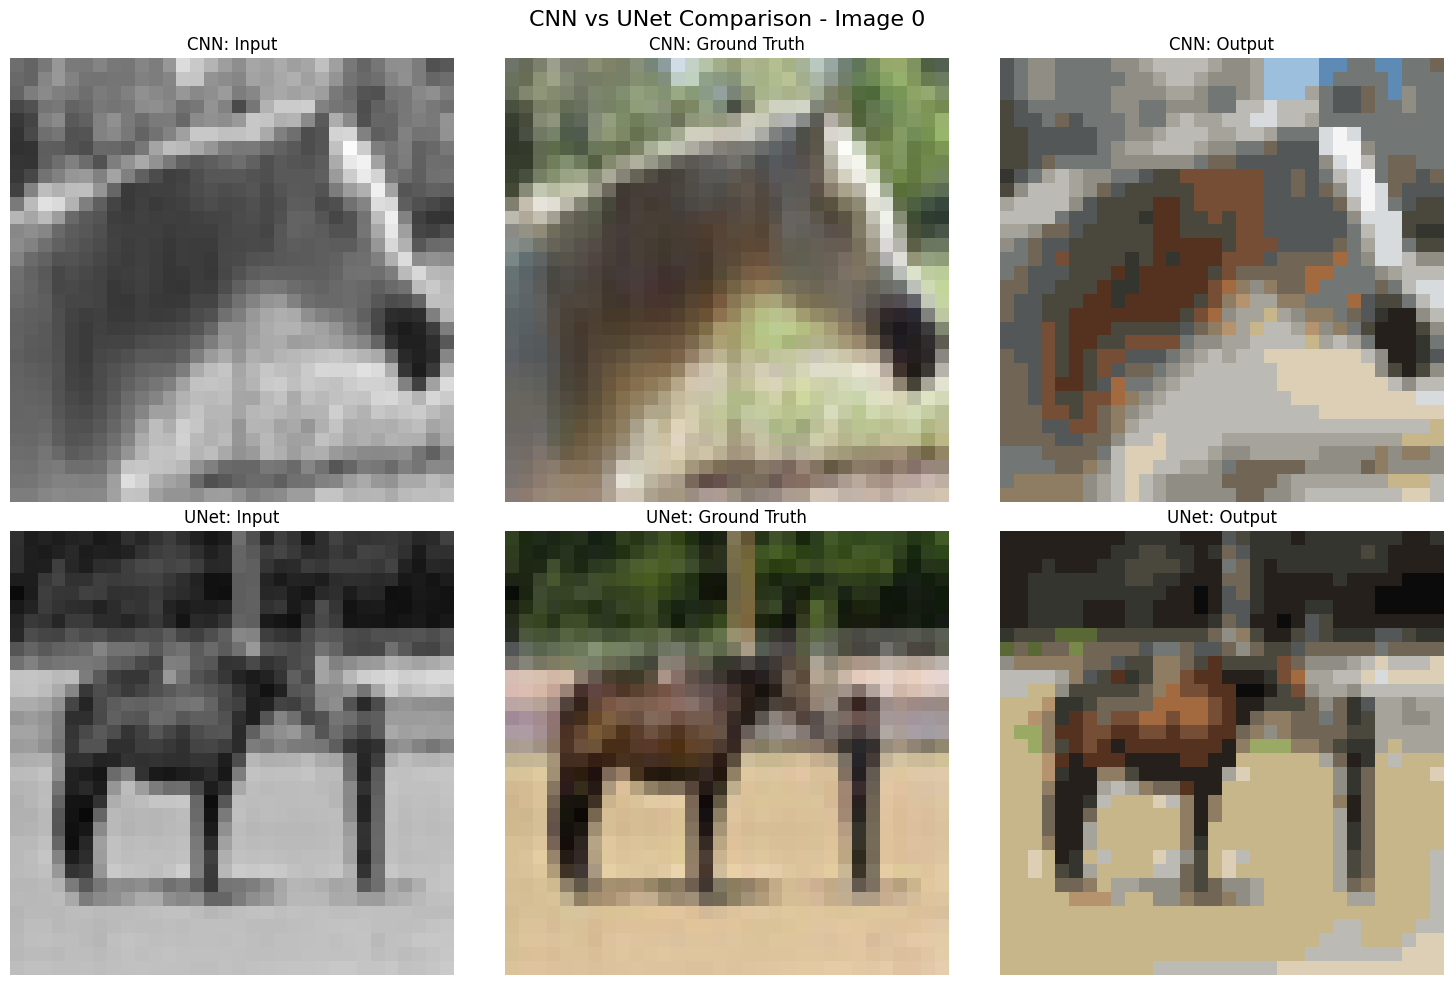


TRAINING CURVES


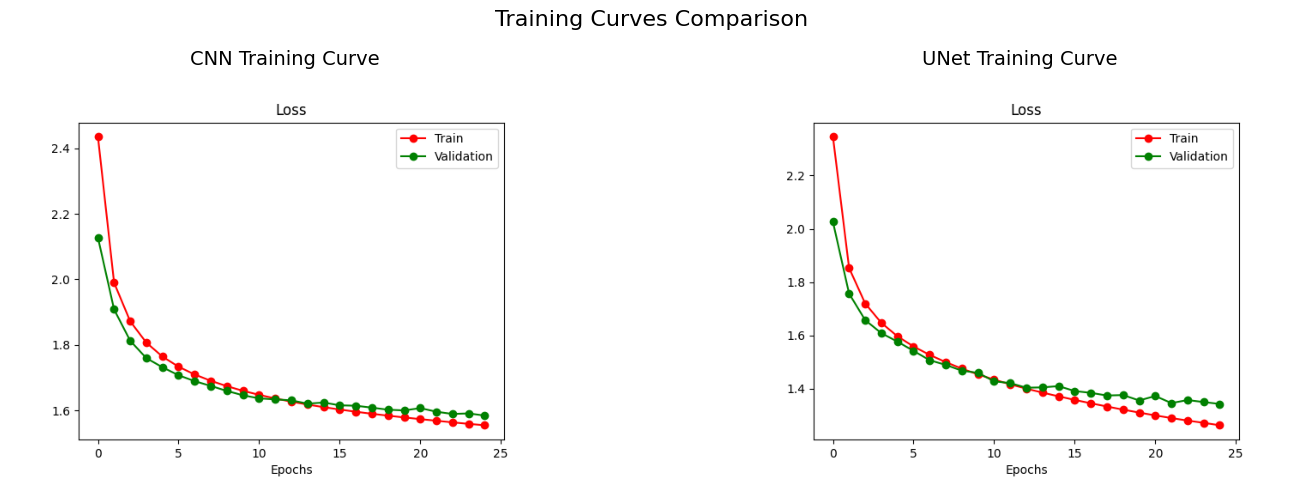

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

%matplotlib inline

def display_colorization_results(experiment_name='colourization_cnn', index=0):
    outdir = f"outputs/{experiment_name}/act{index}"
    
    if not os.path.exists(outdir):
        print(f"Directory not found: {outdir}")
        return
    
    try:
        input_img = Image.open(os.path.join(outdir, f"input_{index}.png"))
        gt_img = Image.open(os.path.join(outdir, f"input_{index}_gt.png"))
        output_img = Image.open(os.path.join(outdir, f"output_{index}.png"))
    except FileNotFoundError as e:
        print(f"File not found: {e}")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(input_img)
    axes[0].set_title('Grayscale Input', fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(gt_img)
    axes[1].set_title('Ground Truth', fontsize=14)
    axes[1].axis('off')
    
    axes[2].imshow(output_img)
    axes[2].set_title('Model Output', fontsize=14)
    axes[2].axis('off')
    
    plt.suptitle(f'{experiment_name.upper()} - Test Image {index}', fontsize=16)
    plt.tight_layout()
    plt.show()

def display_activations(experiment_name='colourization_cnn', index=0, num_layers=5):
    outdir = f"outputs/{experiment_name}/act{index}"
    
    if not os.path.exists(outdir):
        print(f"Directory not found: {outdir}")
        return
    
    fig, axes = plt.subplots(1, num_layers, figsize=(20, 4))
    
    for i in range(num_layers):
        act_path = os.path.join(outdir, f"conv{i+1}_out_{index}.png")
        if os.path.exists(act_path):
            act_img = Image.open(act_path)
            axes[i].imshow(act_img)
            axes[i].set_title(f'Conv {i+1} Activations', fontsize=12)
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, 'Not Found', ha='center', va='center')
            axes[i].set_title(f'Conv {i+1}', fontsize=12)
    
    plt.suptitle(f'{experiment_name.upper()} - Intermediate Activations', fontsize=16)
    plt.tight_layout()
    plt.show()

def compare_cnn_vs_unet(index=0):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    models = ['colourization_cnn', 'colourization_unet']
    titles = ['CNN', 'UNet']
    
    for row, (model_name, title) in enumerate(zip(models, titles)):
        model_dir = f"outputs/{model_name}/act{index}"
        
        if not os.path.exists(model_dir):
            print(f"Directory not found: {model_dir}")
            continue
        
        try:
            axes[row, 0].imshow(Image.open(os.path.join(model_dir, f"input_{index}.png")))
            axes[row, 0].set_title(f'{title}: Input', fontsize=12)
            axes[row, 0].axis('off')
            
            axes[row, 1].imshow(Image.open(os.path.join(model_dir, f"input_{index}_gt.png")))
            axes[row, 1].set_title(f'{title}: Ground Truth', fontsize=12)
            axes[row, 1].axis('off')
            
            axes[row, 2].imshow(Image.open(os.path.join(model_dir, f"output_{index}.png")))
            axes[row, 2].set_title(f'{title}: Output', fontsize=12)
            axes[row, 2].axis('off')
        except FileNotFoundError as e:
            print(f"File not found for {title}: {e}")
    
    plt.suptitle(f'CNN vs UNet Comparison - Image {index}', fontsize=16)
    plt.tight_layout()
    plt.show()

def display_training_curves():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    cnn_curve = "outputs/colourization_cnn/training_curve.png"
    if os.path.exists(cnn_curve):
        axes[0].imshow(Image.open(cnn_curve))
        axes[0].set_title('CNN Training Curve', fontsize=14)
        axes[0].axis('off')
    else:
        axes[0].text(0.5, 0.5, 'CNN curve not found', ha='center', va='center')
        axes[0].set_title('CNN Training Curve', fontsize=14)
    
    unet_curve = "outputs/colourization_unet/training_curve.png"
    if os.path.exists(unet_curve):
        axes[1].imshow(Image.open(unet_curve))
        axes[1].set_title('UNet Training Curve', fontsize=14)
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, 'UNet curve not found', ha='center', va='center')
        axes[1].set_title('UNet Training Curve', fontsize=14)
    
    plt.suptitle('Training Curves Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

print("=" * 60)
print("DISPLAYING CNN RESULTS")
print("=" * 60)
display_colorization_results('colourization_cnn', index=0)
display_activations('colourization_cnn', index=0)

print("\n" + "=" * 60)
print("DISPLAYING UNET RESULTS")
print("=" * 60)
display_colorization_results('colourization_unet', index=0)
display_activations('colourization_unet', index=0)

print("\n" + "=" * 60)
print("COMPARING CNN vs UNET")
print("=" * 60)
compare_cnn_vs_unet(index=0)

print("\n" + "=" * 60)
print("TRAINING CURVES")
print("=" * 60)
display_training_curves()

In [1]:

from __future__ import print_function
import math
import numpy as np
import numpy.random as npr
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
import os
import sys

from six.moves.urllib.request import urlretrieve
import tarfile
import pickle

def get_file(fname, origin, untar=False, cache_dir='data'):
    datadir = os.path.join(cache_dir)
    if not os.path.exists(datadir):
        os.makedirs(datadir)
    if untar:
        untar_fpath = os.path.join(datadir, fname)
        fpath = untar_fpath + '.tar.gz'
    else:
        fpath = os.path.join(datadir, fname)
    print(fpath)
    if not os.path.exists(fpath):
        print('Downloading data from', origin)
        try:
            urlretrieve(origin, fpath)
        except Exception as e:
            raise Exception(f"URL fetch failure on {origin}: {e}")
    if untar:
        if not os.path.exists(untar_fpath):
            print('Extracting file.')
            with tarfile.open(fpath) as archive:
                archive.extractall(datadir)
        return untar_fpath
    return fpath

def load_batch(fpath, label_key='labels'):
    with open(fpath, 'rb') as f:
        if sys.version_info < (3,):
            d = pickle.load(f)
        else:
            d = pickle.load(f, encoding='bytes')
        d_decoded = {}
        for k, v in d.items():
            d_decoded[k.decode('utf8')] = v
        d = d_decoded
    data = d['data']
    labels = d[label_key]
    data = data.reshape(data.shape[0], 3, 32, 32)
    return data, labels

def load_cifar10(transpose=False):
    dirname = 'cifar-10-batches-py'
    origin = 'http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
    path = get_file(dirname, origin=origin, untar=True)
    num_train_samples = 50000
    x_train = np.zeros((num_train_samples, 3, 32, 32), dtype='uint8')
    y_train = np.zeros((num_train_samples,), dtype='uint8')
    for i in range(1, 6):
        fpath = os.path.join(path, 'data_batch_' + str(i))
        data, labels = load_batch(fpath)
        x_train[(i - 1) * 10000: i * 10000, :, :, :] = data
        y_train[(i - 1) * 10000: i * 10000] = labels
    fpath = os.path.join(path, 'test_batch')
    x_test, y_test = load_batch(fpath)
    y_train = np.reshape(y_train, (len(y_train), 1))
    y_test = np.reshape(y_test, (len(y_test), 1))
    if transpose:
        x_train = x_train.transpose(0, 2, 3, 1)
        x_test = x_test.transpose(0, 2, 3, 1)
    return (x_train, y_train), (x_test, y_test)

colours_fpath = get_file(fname='colours', 
                         origin='http://www.cs.toronto.edu/~jba/kmeans_colour_a2.tar.gz', 
                         untar=True)

HORSE_CATEGORY = 7

def process(xs, ys, max_pixel=256.0):
    xs = xs / max_pixel
    xs = xs[np.where(ys == HORSE_CATEGORY)[0], :, :, :]
    npr.shuffle(xs)
    grey = np.mean(xs, axis=1, keepdims=True)
    return xs, grey

def get_batch(x, y, batch_size):
    N = np.shape(x)[0]
    for i in range(0, N, batch_size):
        yield (x[i:i+batch_size, :,:,:], y[i:i+batch_size, :,:,:])

def get_torch_vars(xs, ys, gpu=False):
    xs = torch.from_numpy(xs).float()
    ys = torch.from_numpy(ys).float()
    if gpu and torch.cuda.is_available():
        xs = xs.cuda()
        ys = ys.cuda()
    return Variable(xs), Variable(ys)

class MyConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=None):
        super(MyConv2d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        if padding is None:
            self.padding = kernel_size // 2
        else:
            self.padding = padding
        self.weight = nn.parameter.Parameter(torch.Tensor(
            out_channels, in_channels, kernel_size, kernel_size))
        self.bias = nn.parameter.Parameter(torch.Tensor(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        n = self.in_channels * self.kernel_size * self.kernel_size
        stdv = 1. / math.sqrt(n)
        self.weight.data.uniform_(-stdv, stdv)
        self.bias.data.uniform_(-stdv, stdv)

    def forward(self, input):
        return F.conv2d(input, self.weight, self.bias, padding=self.padding)

class RegressionCNN(nn.Module):
    """
    REGRESSION-BASED CNN for Colorization.
    Input: Grayscale [B, 1, 32, 32]
    Output: RGB [B, 3, 32, 32]
    Loss: MSE (Mean Squared Error)
    """
    def __init__(self, kernel, num_filters):
        super(RegressionCNN, self).__init__()
        padding = kernel // 2
        
        self.conv1 = nn.Sequential(
            MyConv2d(1, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.conv2 = nn.Sequential(
            MyConv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.conv3 = nn.Sequential(
            MyConv2d(num_filters*2, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
        )
        self.conv4 = nn.Sequential(
            MyConv2d(num_filters*2, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
        )
        self.conv5 = nn.Sequential(
            MyConv2d(num_filters, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
        )
        self.conv6 = MyConv2d(num_filters, 3, kernel_size=kernel, padding=padding)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = torch.sigmoid(x)
        return x

def compute_mse_loss(outputs, targets, batch_size):
    """
    MSE Loss for Regression.
    outputs: [B, 3, 32, 32]
    targets: [B, 3, 32, 32]
    """
    return F.mse_loss(outputs, targets)

def plot_regression(input, gt, output, path, visualize=False):
    grey = np.transpose(input[:10, :, :, :], [0, 2, 3, 1])
    gt_display = np.transpose(gt[:10, :, :, :], [0, 2, 3, 1])
    pred_display = np.transpose(output[:10, :, :, :], [0, 2, 3, 1])
    
    img_stack = [
        np.hstack(np.tile(grey, [1, 1, 1, 3])),
        np.hstack(gt_display),
        np.hstack(pred_display)
    ]
    
    img = np.vstack(img_stack)
    plt.grid('off')
    plt.imshow(np.clip(img, 0, 1), vmin=0., vmax=1.)
    
    if visualize:
        plt.show()
    else:
        plt.savefig(path)
    plt.close()

def run_validation_regression(cnn, criterion, test_grey, test_rgb, batch_size, 
                              plotpath=None, visualize=False, gpu=False):
    total_loss = 0.0
    num_batches = 0
    
    for i, (xs, ys) in enumerate(get_batch(test_grey, test_rgb, batch_size)):
        images, targets = get_torch_vars(xs, ys, gpu)
        outputs = cnn(images)
        loss = criterion(outputs, targets)
        total_loss += loss.data.item()
        num_batches += 1
        
        if plotpath and i == 0:
            plot_regression(xs, ys, outputs.cpu().data.numpy(), plotpath, visualize)
    
    return total_loss / num_batches

class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

def train_regression(args, cnn=None):
    torch.set_num_threads(5)
    npr.seed(args.seed)
    
    save_dir = "outputs/" + args.experiment_name
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    if cnn is None:
        cnn = RegressionCNN(args.kernel, args.num_filters)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(cnn.parameters(), lr=args.learn_rate)
    
    print("Loading data...")
    (x_train, y_train), (x_test, y_test) = load_cifar10()
    print("Transforming data...")
    train_rgb, train_grey = process(x_train, y_train)
    test_rgb, test_grey = process(x_test, y_test)
    
    print("Beginning training ...")
    if args.gpu and torch.cuda.is_available():
        cnn.cuda()
        print("Using GPU")
    else:
        print("Using CPU")
    
    start = time.time()
    train_losses = []
    valid_losses = []
    
    for epoch in range(args.epochs):
        cnn.train()
        losses = []
        
        for i, (xs, ys) in enumerate(get_batch(train_grey, train_rgb, args.batch_size)):
            images, targets = get_torch_vars(xs, ys, args.gpu and torch.cuda.is_available())
            
            optimizer.zero_grad()
            outputs = cnn(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            losses.append(loss.data.item())
            
            if args.plot and i == 0:
                plot_regression(xs, ys, outputs.cpu().data.numpy(), 
                              save_dir + '/train_%d.png' % epoch)
        
        avg_loss = np.mean(losses)
        train_losses.append(avg_loss)
        time_elapsed = time.time() - start
        print('Epoch [%d/%d], Train Loss: %.4f, Time (s): %d' % 
              (epoch+1, args.epochs, avg_loss, time_elapsed))
        
        cnn.eval()
        val_loss = run_validation_regression(cnn, criterion, test_grey, test_rgb,
                                            args.batch_size, 
                                            save_dir + '/test_%d.png' % epoch,
                                            args.gpu and torch.cuda.is_available())
        time_elapsed = time.time() - start
        valid_losses.append(val_loss)
        print('Epoch [%d/%d], Val Loss: %.4f, Time(s): %d' % 
              (epoch+1, args.epochs, val_loss, time_elapsed))
    
    plt.figure()
    plt.plot(train_losses, "ro-", label="Train")
    plt.plot(valid_losses, "go-", label="Validation")
    plt.legend()
    plt.title("MSE Loss")
    plt.xlabel("Epochs")
    plt.savefig(save_dir + "/training_curve.png")
    plt.close()
    
    if args.checkpoint:
        print('Saving model...')
        torch.save(cnn.state_dict(), args.checkpoint)
    
    return cnn, train_losses, valid_losses

def train_multiple_epochs():
    """
    Train models with different epoch counts for comparison.
    """
    epoch_counts = [5, 10, 25, 50]
    results = {}
    
    for epochs in epoch_counts:
        print("\n" + "=" * 60)
        print(f"TRAINING REGRESSION CNN FOR {epochs} EPOCHS")
        print("=" * 60)
        
        args = AttrDict()
        args_dict = {
            'gpu': False,
            'checkpoint': f"outputs/regression_cnn_e{epochs}.pth",
            'kernel': 3,
            'num_filters': 32,
            'learn_rate': 0.001,
            'batch_size': 100,
            'epochs': epochs,
            'seed': 0,
            'plot': True,
            'experiment_name': f'regression_cnn_epochs_{epochs}',
            'visualize': False,
        }
        args.update(args_dict)
        
        cnn, train_losses, val_losses = train_regression(args)
        results[epochs] = {
            'model': cnn,
            'train_losses': train_losses,
            'val_losses': val_losses
        }
    
    return results

def compare_epoch_results(results):
    """
    Visualize and compare results from different epoch counts.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    for idx, (epochs, data) in enumerate(results.items()):
        row, col = idx // 2, idx % 2
        
        axes[row, col].plot(data['train_losses'], 'b-', label='Train')
        axes[row, col].plot(data['val_losses'], 'r-', label='Val')
        axes[row, col].set_title(f'{epochs} Epochs')
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel('MSE Loss')
        axes[row, col].legend()
        axes[row, col].grid(True)
    
    plt.suptitle('Training Progress: Effect of Epoch Count', fontsize=14)
    plt.tight_layout()
    plt.savefig('outputs/epoch_comparison.png')
    plt.show()
    
    print("\n" + "=" * 60)
    print("FINAL RESULTS COMPARISON")
    print("=" * 60)
    print(f"{'Epochs':<10} {'Final Train Loss':<20} {'Final Val Loss':<20}")
    print("-" * 60)
    for epochs, data in results.items():
        print(f"{epochs:<10} {data['train_losses'][-1]:<20.4f} {data['val_losses'][-1]:<20.4f}")

if __name__ == "__main__":
    results = train_multiple_epochs()
    compare_epoch_results(results)

data\colours.tar.gz

TRAINING REGRESSION CNN FOR 5 EPOCHS
Loading data...
data\cifar-10-batches-py.tar.gz
Transforming data...


C:\Users\exam\AppData\Local\Temp\ipykernel_2580\1313704658.py:50: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='bytes')


Beginning training ...
Using CPU
Epoch [1/5], Train Loss: 0.0177, Time (s): 3
Epoch [1/5], Val Loss: 0.0124, Time(s): 4
Epoch [2/5], Train Loss: 0.0105, Time (s): 7
Epoch [2/5], Val Loss: 0.0098, Time(s): 8
Epoch [3/5], Train Loss: 0.0092, Time (s): 12
Epoch [3/5], Val Loss: 0.0090, Time(s): 12
Epoch [4/5], Train Loss: 0.0085, Time (s): 16
Epoch [4/5], Val Loss: 0.0084, Time(s): 16
Epoch [5/5], Train Loss: 0.0081, Time (s): 19
Epoch [5/5], Val Loss: 0.0079, Time(s): 20
Saving model...

TRAINING REGRESSION CNN FOR 10 EPOCHS
Loading data...
data\cifar-10-batches-py.tar.gz
Transforming data...
Beginning training ...
Using CPU
Epoch [1/10], Train Loss: 0.0180, Time (s): 3
Epoch [1/10], Val Loss: 0.0119, Time(s): 3
Epoch [2/10], Train Loss: 0.0103, Time (s): 7
Epoch [2/10], Val Loss: 0.0096, Time(s): 7
Epoch [3/10], Train Loss: 0.0090, Time (s): 11
Epoch [3/10], Val Loss: 0.0087, Time(s): 11
Epoch [4/10], Train Loss: 0.0083, Time (s): 15
Epoch [4/10], Val Loss: 0.0081, Time(s): 15
Epoch [5/

C:\Users\exam\AppData\Local\Temp\ipykernel_2580\1313704658.py:371: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


REGRESSION CNN RESULTS

--- 5 Epochs ---
Directory not found: outputs/regression_cnn_epochs_5/act0

--- 10 Epochs ---
Directory not found: outputs/regression_cnn_epochs_10/act0

--- 25 Epochs ---
Directory not found: outputs/regression_cnn_epochs_25/act0

--- 50 Epochs ---
Directory not found: outputs/regression_cnn_epochs_50/act0

TRAINING CURVES COMPARISON


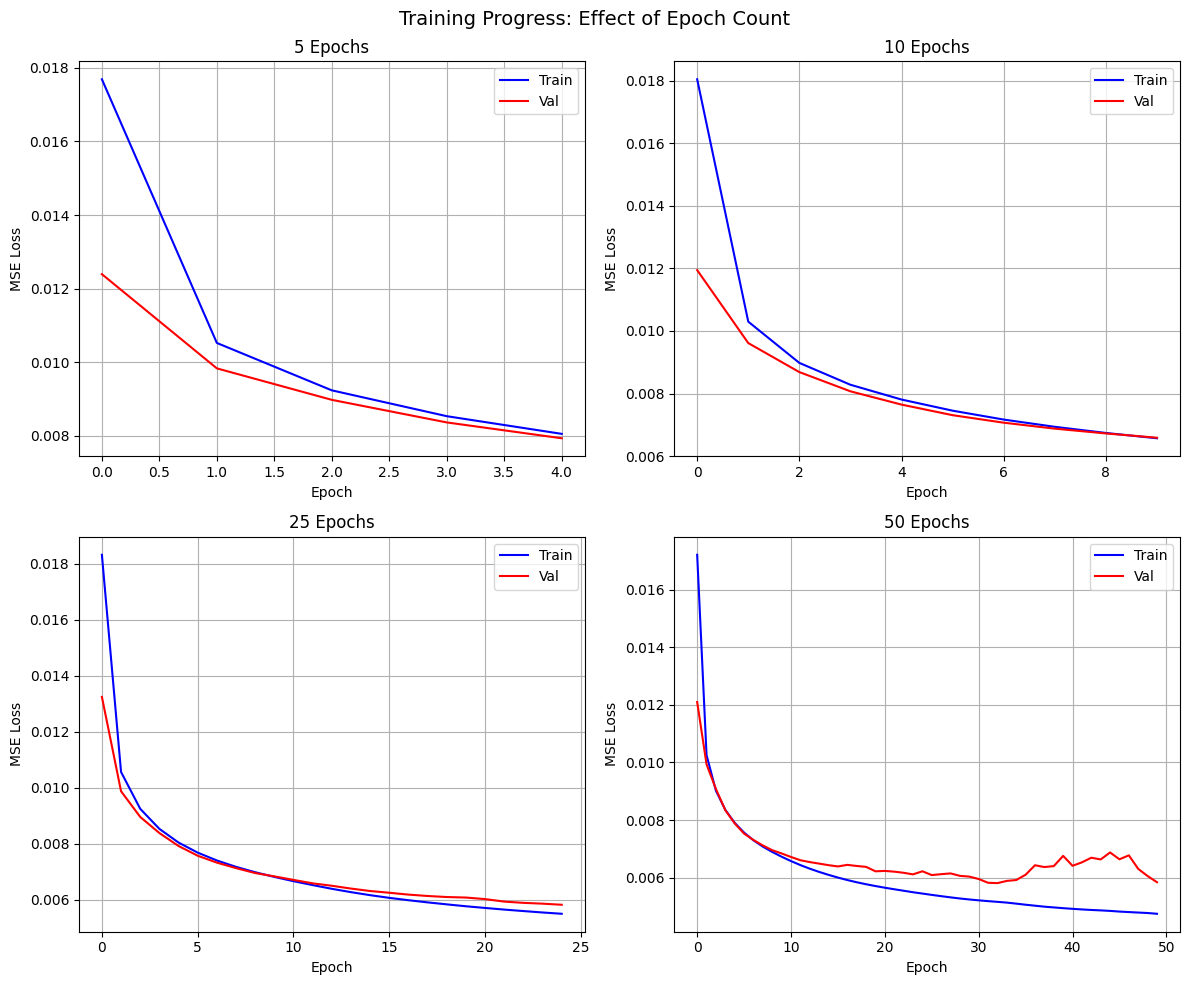

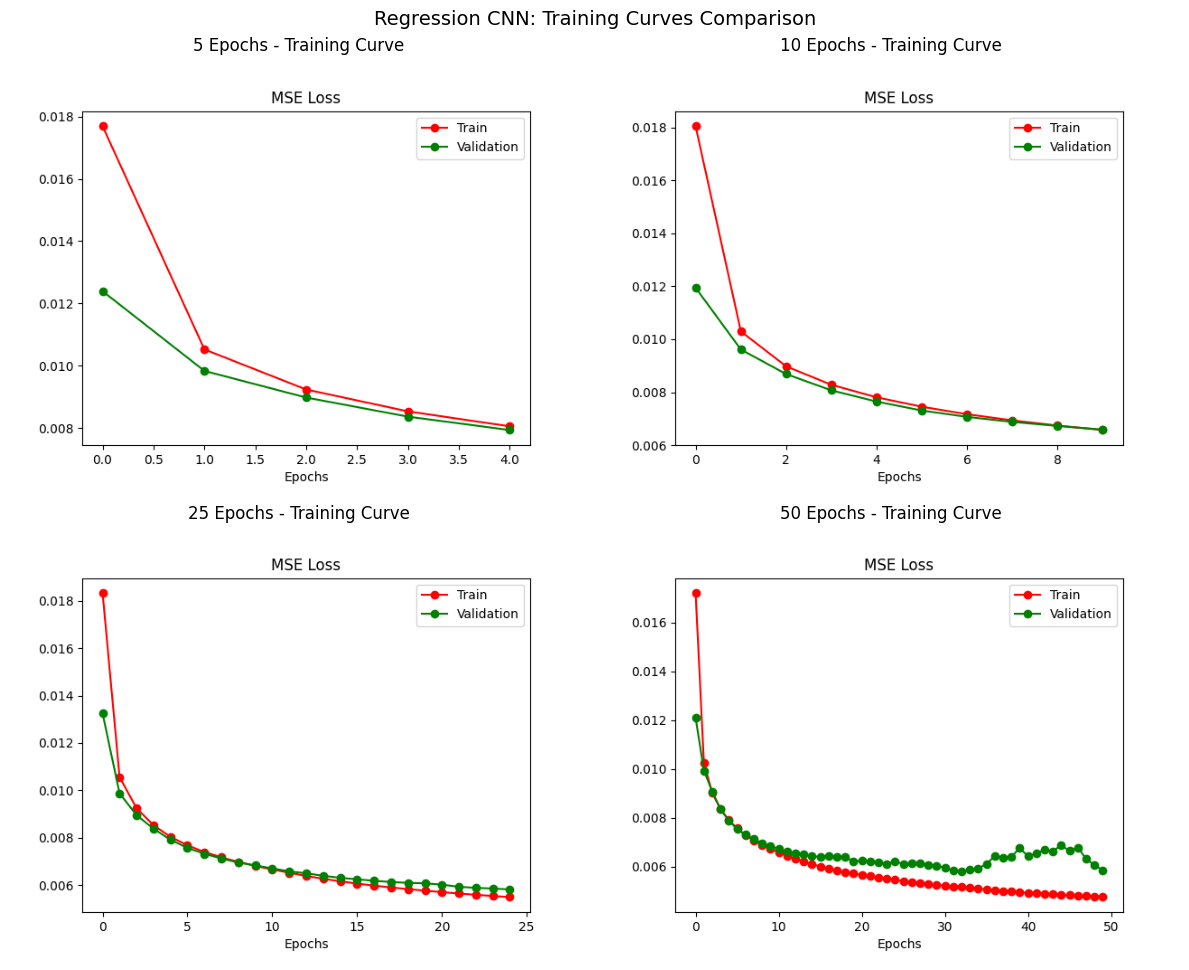


ALL EPOCHS COMPARISON


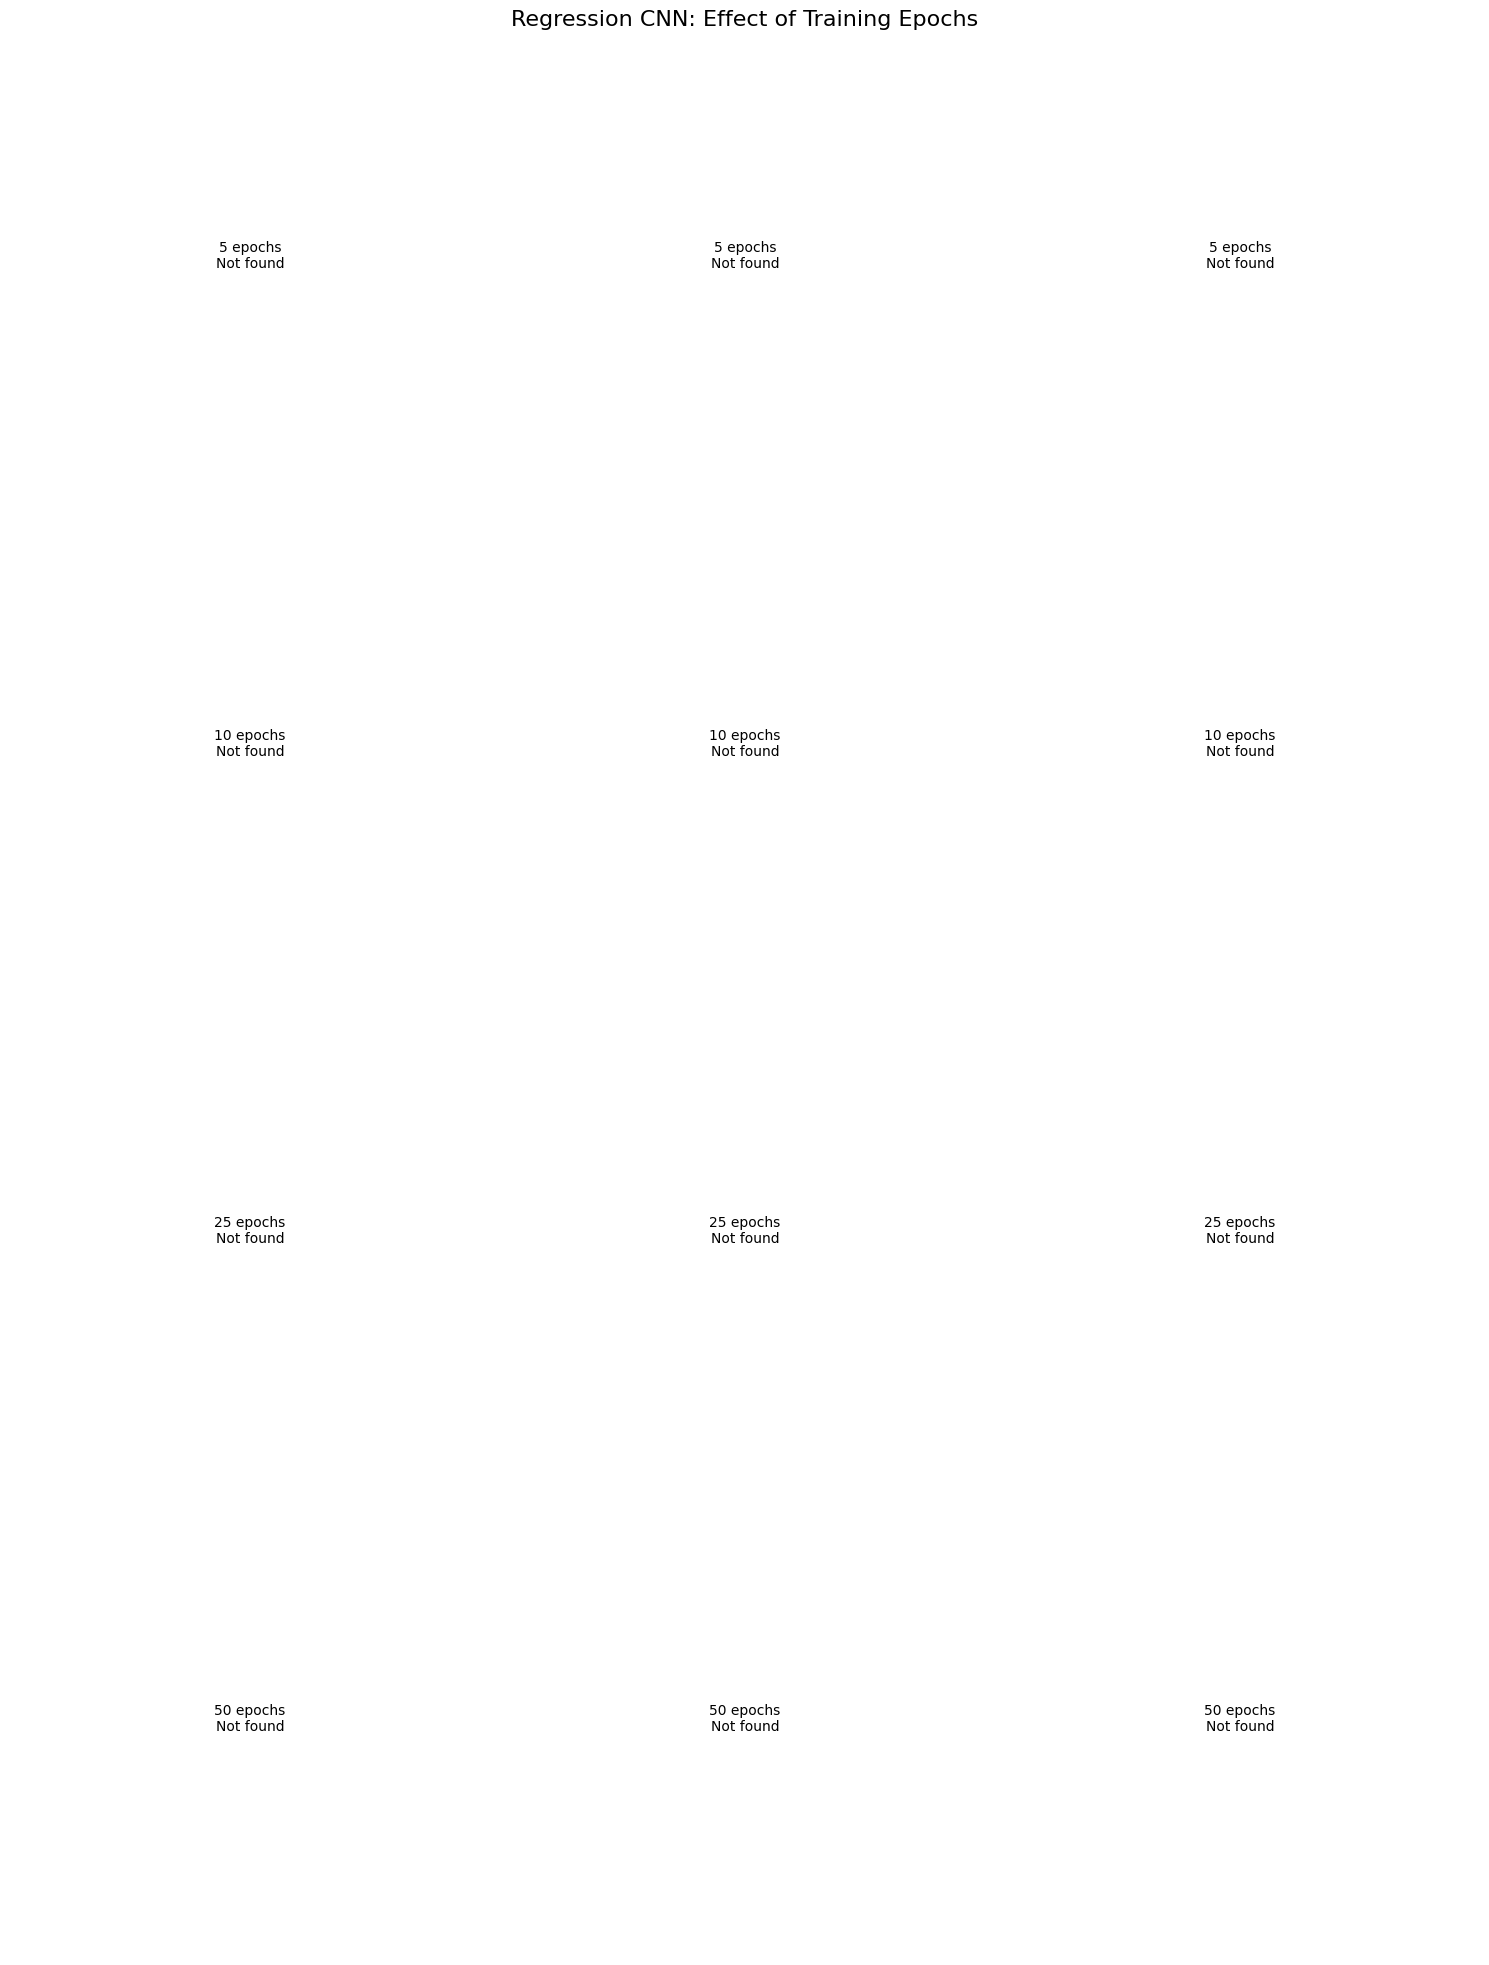

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

%matplotlib inline

def display_regression_results(experiment_name='regression_cnn_epochs_25', index=0):
    outdir = f"outputs/{experiment_name}/act{index}"
    if not os.path.exists(outdir):
        print(f"Directory not found: {outdir}")
        return
    try:
        input_img = Image.open(os.path.join(outdir, f"input_{index}.png"))
        gt_img = Image.open(os.path.join(outdir, f"input_{index}_gt.png"))
        output_img = Image.open(os.path.join(outdir, f"output_{index}.png"))
    except FileNotFoundError as e:
        print(f"File not found: {e}")
        return
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(input_img)
    axes[0].set_title('Grayscale Input', fontsize=14)
    axes[0].axis('off')
    axes[1].imshow(gt_img)
    axes[1].set_title('Ground Truth', fontsize=14)
    axes[1].axis('off')
    axes[2].imshow(output_img)
    axes[2].set_title('Regression Output', fontsize=14)
    axes[2].axis('off')
    plt.suptitle(f'{experiment_name.upper()} - Test Image {index}', fontsize=16)
    plt.tight_layout()
    plt.show()

def display_training_curves_comparison():
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    epoch_counts = [5, 10, 25, 50]
    for idx, epochs in enumerate(epoch_counts):
        row, col = idx // 2, idx % 2
        curve_path = f"outputs/regression_cnn_epochs_{epochs}/training_curve.png"
        if os.path.exists(curve_path):
            axes[row, col].imshow(Image.open(curve_path))
            axes[row, col].set_title(f'{epochs} Epochs - Training Curve', fontsize=12)
            axes[row, col].axis('off')
        else:
            axes[row, col].text(0.5, 0.5, f'{epochs} epochs\nNot found', ha='center', va='center')
            axes[row, col].set_title(f'{epochs} Epochs', fontsize=12)
    plt.suptitle('Regression CNN: Training Curves Comparison', fontsize=14)
    plt.tight_layout()
    plt.show()

def compare_all_epoch_outputs(index=0):
    fig, axes = plt.subplots(4, 3, figsize=(15, 20))
    epoch_counts = [5, 10, 25, 50]
    for row, epochs in enumerate(epoch_counts):
        exp_name = f'regression_cnn_epochs_{epochs}'
        outdir = f"outputs/{exp_name}/act{index}"
        if not os.path.exists(outdir):
            for col in range(3):
                axes[row, col].text(0.5, 0.5, f'{epochs} epochs\nNot found', ha='center', va='center')
                axes[row, col].axis('off')
            continue
        try:
            axes[row, 0].imshow(Image.open(os.path.join(outdir, f"input_{index}.png")))
            axes[row, 0].set_title(f'{epochs} Epochs: Input')
            axes[row, 0].axis('off')
            axes[row, 1].imshow(Image.open(os.path.join(outdir, f"input_{index}_gt.png")))
            axes[row, 1].set_title(f'{epochs} Epochs: Ground Truth')
            axes[row, 1].axis('off')
            axes[row, 2].imshow(Image.open(os.path.join(outdir, f"output_{index}.png")))
            axes[row, 2].set_title(f'{epochs} Epochs: Output')
            axes[row, 2].axis('off')
        except FileNotFoundError:
            for col in range(3):
                axes[row, col].text(0.5, 0.5, 'File not found', ha='center', va='center')
                axes[row, col].axis('off')
    plt.suptitle('Regression CNN: Effect of Training Epochs', fontsize=16)
    plt.tight_layout()
    plt.show()

print("=" * 60)
print("REGRESSION CNN RESULTS")
print("=" * 60)
print("\n--- 5 Epochs ---")
display_regression_results('regression_cnn_epochs_5', index=0)
print("\n--- 10 Epochs ---")
display_regression_results('regression_cnn_epochs_10', index=0)
print("\n--- 25 Epochs ---")
display_regression_results('regression_cnn_epochs_25', index=0)
print("\n--- 50 Epochs ---")
display_regression_results('regression_cnn_epochs_50', index=0)
print("\n" + "=" * 60)
print("TRAINING CURVES COMPARISON")
print("=" * 60)
display_training_curves_comparison()
print("\n" + "=" * 60)
print("ALL EPOCHS COMPARISON")
print("=" * 60)
compare_all_epoch_outputs(index=0)